In [2]:
import common_imports
from common_imports import *


In [3]:
# preprocess + architecture + weights (as in 3.ipynb — no training / torchinfo).
def preprocess(file_path):
    """Load image from disk → float32 tensor [3, 100, 100], RGB, values in [0, 1]."""
    img_bgr = cv2.imread(str(file_path))
    if img_bgr is None:
        raise ValueError(f"Could not read image: {file_path!r}")
    img_bgr = cv2.resize(img_bgr, (100, 100))
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return torch.from_numpy(rgb).permute(2, 0, 1).contiguous().float() / 255.0


class EmbeddingNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=10),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2, ceil_mode=True),
            nn.Conv2d(64, 128, kernel_size=7),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2, ceil_mode=True),
            nn.Conv2d(128, 128, kernel_size=4),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2, ceil_mode=True),
            nn.Conv2d(128, 256, kernel_size=4),
            nn.ReLU(inplace=True),
            nn.Flatten(),
            nn.Linear(9216, 4096),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.embedding(x)


class L1Dist(nn.Module):
    def forward(self, input_embedding, validation_embedding):
        return torch.abs(input_embedding - validation_embedding)


class SiameseNetwork(nn.Module):
    def __init__(self, embedding_net: nn.Module):
        super().__init__()
        self.embedding = embedding_net
        self.l1 = L1Dist()
        self.classifier = nn.Linear(4096, 1)

    def forward(self, input_img, validation_img):
        inp_e = self.embedding(input_img)
        val_e = self.embedding(validation_img)
        distances = self.l1(inp_e, val_e)
        return torch.sigmoid(self.classifier(distances))


_PART_2_ROOT = os.path.dirname(os.path.dirname(ANC_PATH))
weights_path = os.path.join(_PART_2_ROOT, "siamesemodelv2.pt")
if not os.path.isfile(weights_path):
    raise FileNotFoundError(
        f"Missing weights: {weights_path!r} — train and save in 3.ipynb (torch.save) or copy the .pt into Part_2."
    )

siamese_model = SiameseNetwork(EmbeddingNet())
siamese_model.load_state_dict(torch.load(weights_path, map_location="cpu"))
siamese_model = siamese_model.to(device).eval()
print("Loaded:", weights_path, "| device:", device)


Loaded: /Users/igorhebda/Desktop/HTW-Bio/HTW_Biometrics/siamesemodelv2.pt | device: mps


Samples: 10000 | threshold: 0.97
Class counts -> negatives: 9966, positives: 34

--- Standard metrics ---
Accuracy         : 0.9412
Precision        : 0.0518
Recall (TAR/TPR) : 0.9412
F1-score         : 0.0982
Specificity (TNR): 0.9412
Balanced Accuracy: 0.9412
MCC              : 0.2133

--- Biometrics metrics ---
FAR              : 0.0588
FRR              : 0.0588
EER              : 0.0588 (at threshold=0.9744)
TAR @ FAR<=0.1%  : 0.3235
TAR @ FAR<=1.0%  : 0.7059
ROC-AUC          : 0.9894
PR-AUC           : 0.3531


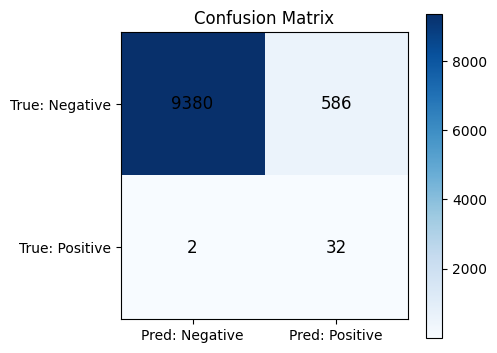

{'accuracy': 0.9411999999990587,
 'precision': 0.051779935274243044,
 'recall': 0.9411764703114187,
 'f1': 0.09815950821088487,
 'specificity': 0.9412000802719834,
 'balanced_accuracy': 0.9411882752917011,
 'mcc': 0.2133103391983186,
 'far': 0.05879991972701304,
 'frr': 0.05882352939446367,
 'eer': 0.058811724560738354,
 'eer_threshold': 0.9744421243667603,
 'tar_at_far_0_1pct': 0.3235294116695502,
 'tar_at_far_1pct': 0.705882352733564,
 'roc_auc': 0.9893800684121952,
 'pr_auc': 0.3531173939244,
 'confusion_matrix': array([[9380,  586],
        [   2,   32]], dtype=int32)}

In [9]:
# Model evaluation: confusion matrix + biometrics-focused metrics
from pathlib import Path


def _list_images(dir_path):
    return sorted([p for p in Path(dir_path).iterdir() if p.suffix.lower() in GALLERY_EXTS])


def _build_eval_pairs(max_pairs=10000):
    """
    Build a larger evaluation set (not necessarily balanced):
    - Positive class (1): anchor[i] vs positive[i]
    - Negative class (0): many anchor[i] vs negative[j] combinations
    """
    anchors = _list_images(ANC_PATH)
    positives = _list_images(POS_PATH)
    negatives = _list_images(NEG_PATH)

    if not anchors or not positives or not negatives:
        raise ValueError("Evaluation data folders are empty. Check data/anchor, data/positive, data/negative.")

    pairs = []

    # Positives: one-to-one up to the shortest list
    n_pos = min(len(anchors), len(positives))
    for i in range(n_pos):
        pairs.append((anchors[i], positives[i], 1))

    # Negatives: all anchor-negative combinations (can dominate, intentionally)
    for a in anchors:
        for n in negatives:
            pairs.append((a, n, 0))

    if max_pairs is not None and len(pairs) > max_pairs:
        pairs = pairs[:max_pairs]

    return pairs


def _safe_div(num, den, eps=1e-8):
    return num / (den + eps)


def _curve_stats(y_true, y_score):
    """
    Build threshold sweep with FAR/FPR, FRR, TPR/Recall, Precision.
    Returns arrays and AUC approximations (ROC-AUC, PR-AUC).
    """
    y_true = np.asarray(y_true, dtype=np.int32)
    y_score = np.asarray(y_score, dtype=np.float32)

    thresholds = np.unique(y_score)[::-1]

    fars, frrs, tprs, fprs, precisions, recalls = [], [], [], [], [], []

    for t in thresholds:
        y_pred = (y_score >= t).astype(np.int32)

        tp = int(((y_true == 1) & (y_pred == 1)).sum())
        tn = int(((y_true == 0) & (y_pred == 0)).sum())
        fp = int(((y_true == 0) & (y_pred == 1)).sum())
        fn = int(((y_true == 1) & (y_pred == 0)).sum())

        far = _safe_div(fp, fp + tn)     # False Accept Rate
        frr = _safe_div(fn, fn + tp)     # False Reject Rate
        tpr = _safe_div(tp, tp + fn)     # True Accept/Recall
        fpr = _safe_div(fp, fp + tn)
        prec = _safe_div(tp, tp + fp)
        rec = tpr

        fars.append(far)
        frrs.append(frr)
        tprs.append(tpr)
        fprs.append(fpr)
        precisions.append(prec)
        recalls.append(rec)

    fars = np.array(fars, dtype=np.float64)
    frrs = np.array(frrs, dtype=np.float64)
    tprs = np.array(tprs, dtype=np.float64)
    fprs = np.array(fprs, dtype=np.float64)
    precisions = np.array(precisions, dtype=np.float64)
    recalls = np.array(recalls, dtype=np.float64)

    # ROC-AUC / PR-AUC via trapezoid integration (NumPy-version safe).
    trapz_fn = getattr(np, "trapezoid", None)
    if trapz_fn is None:
        trapz_fn = getattr(np, "trapz")

    roc_idx = np.argsort(fprs)
    roc_auc = trapz_fn(tprs[roc_idx], fprs[roc_idx])

    pr_idx = np.argsort(recalls)
    pr_auc = trapz_fn(precisions[pr_idx], recalls[pr_idx])

    return {
        "thresholds": thresholds,
        "fars": fars,
        "frrs": frrs,
        "tprs": tprs,
        "fprs": fprs,
        "precisions": precisions,
        "recalls": recalls,
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc),
    }


def _tar_at_far(curve, target_far):
    mask = curve["fars"] <= target_far
    if not np.any(mask):
        return 0.0
    return float(np.max(curve["tprs"][mask]))


def evaluate_model(model, threshold=0.5, max_pairs=10000):
    pairs = _build_eval_pairs(max_pairs=max_pairs)

    y_true = []
    y_score = []

    with torch.no_grad():
        for a_path, b_path, label in pairs:
            a = preprocess(a_path).unsqueeze(0).to(device)
            b = preprocess(b_path).unsqueeze(0).to(device)
            score = model(a, b).item()

            y_true.append(label)
            y_score.append(score)

    y_true = np.array(y_true, dtype=np.int32)
    y_score = np.array(y_score, dtype=np.float32)
    y_pred = (y_score >= threshold).astype(np.int32)

    # Confusion matrix values at selected threshold
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    accuracy = _safe_div(tp + tn, len(y_true))
    precision = _safe_div(tp, tp + fp)
    recall = _safe_div(tp, tp + fn)
    f1 = _safe_div(2 * precision * recall, precision + recall)
    specificity = _safe_div(tn, tn + fp)  # TNR
    balanced_accuracy = 0.5 * (recall + specificity)
    mcc = _safe_div((tp * tn) - (fp * fn), np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)))

    # Biometrics metrics at threshold
    far = _safe_div(fp, fp + tn)
    frr = _safe_div(fn, fn + tp)

    # Threshold sweep metrics (EER, TAR@FAR, ROC-AUC, PR-AUC)
    curve = _curve_stats(y_true, y_score)
    eer_idx = int(np.argmin(np.abs(curve["fars"] - curve["frrs"])))
    eer = float(0.5 * (curve["fars"][eer_idx] + curve["frrs"][eer_idx]))
    eer_threshold = float(curve["thresholds"][eer_idx])

    tar_far_01 = _tar_at_far(curve, target_far=0.001)  # 0.1%
    tar_far_1 = _tar_at_far(curve, target_far=0.01)    # 1%

    print(f"Samples: {len(y_true)} | threshold: {threshold:.2f}")
    print(f"Class counts -> negatives: {(y_true == 0).sum()}, positives: {(y_true == 1).sum()}")
    print("\n--- Standard metrics ---")
    print(f"Accuracy         : {accuracy:.4f}")
    print(f"Precision        : {precision:.4f}")
    print(f"Recall (TAR/TPR) : {recall:.4f}")
    print(f"F1-score         : {f1:.4f}")
    print(f"Specificity (TNR): {specificity:.4f}")
    print(f"Balanced Accuracy: {balanced_accuracy:.4f}")
    print(f"MCC              : {mcc:.4f}")

    print("\n--- Biometrics metrics ---")
    print(f"FAR              : {far:.4f}")
    print(f"FRR              : {frr:.4f}")
    print(f"EER              : {eer:.4f} (at threshold={eer_threshold:.4f})")
    print(f"TAR @ FAR<=0.1%  : {tar_far_01:.4f}")
    print(f"TAR @ FAR<=1.0%  : {tar_far_1:.4f}")
    print(f"ROC-AUC          : {curve['roc_auc']:.4f}")
    print(f"PR-AUC           : {curve['pr_auc']:.4f}")

    cm = np.array([[tn, fp], [fn, tp]], dtype=np.int32)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap="Blues")
    plt.title("Confusion Matrix")
    plt.colorbar()
    plt.xticks([0, 1], ["Pred: Negative", "Pred: Positive"])
    plt.yticks([0, 1], ["True: Negative", "True: Positive"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=12)

    plt.tight_layout()
    plt.show()

    return {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "specificity": float(specificity),
        "balanced_accuracy": float(balanced_accuracy),
        "mcc": float(mcc),
        "far": float(far),
        "frr": float(frr),
        "eer": float(eer),
        "eer_threshold": float(eer_threshold),
        "tar_at_far_0_1pct": float(tar_far_01),
        "tar_at_far_1pct": float(tar_far_1),
        "roc_auc": float(curve["roc_auc"]),
        "pr_auc": float(curve["pr_auc"]),
        "confusion_matrix": cm,
    }


metrics = evaluate_model(siamese_model, threshold=0.9744, max_pairs=10000)
metrics

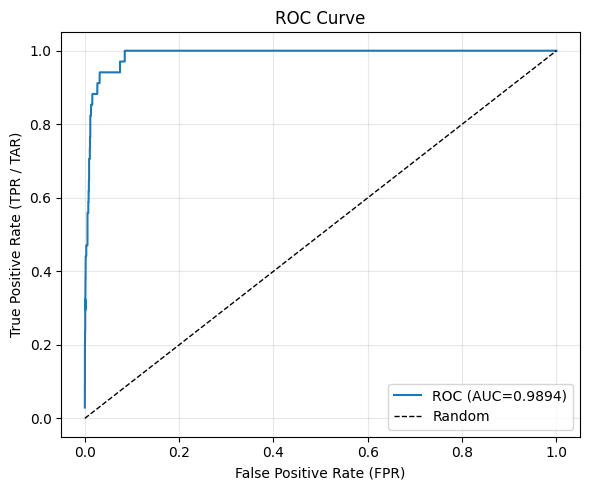

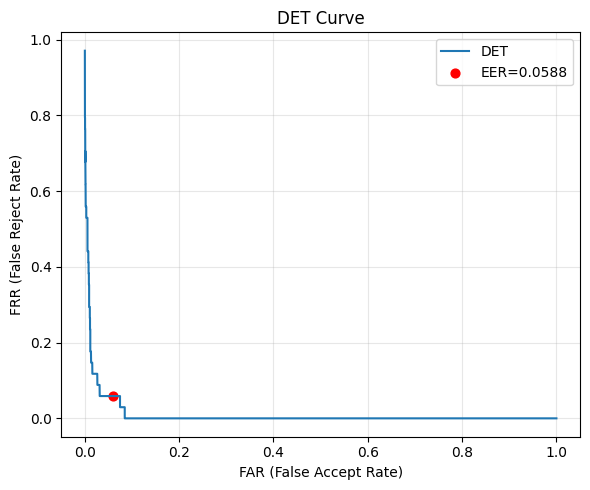

{'roc_auc': 0.9893800684121952, 'eer': 0.058811724560738354}

In [11]:
# Extra plots in a separate cell: ROC + DET (with EER point)
# Reuses helpers from the previous cell: _build_eval_pairs, _curve_stats, preprocess, siamese_model

def plot_biometrics_curves(model, max_pairs=10000):
    pairs = _build_eval_pairs(max_pairs=max_pairs)

    y_true = []
    y_score = []

    with torch.no_grad():
        for a_path, b_path, label in pairs:
            a = preprocess(a_path).unsqueeze(0).to(device)
            b = preprocess(b_path).unsqueeze(0).to(device)
            score = model(a, b).item()
            y_true.append(label)
            y_score.append(score)

    curve = _curve_stats(np.array(y_true), np.array(y_score))

    # EER point: threshold where FAR and FRR are closest
    eer_idx = int(np.argmin(np.abs(curve["fars"] - curve["frrs"])))
    eer = float(0.5 * (curve["fars"][eer_idx] + curve["frrs"][eer_idx]))

    # ROC curve
    plt.figure(figsize=(6, 5))
    order = np.argsort(curve["fprs"])
    plt.plot(curve["fprs"][order], curve["tprs"][order], label=f"ROC (AUC={curve['roc_auc']:.4f})")
    plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR / TAR)")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # DET curve (FAR vs FRR)
    plt.figure(figsize=(6, 5))
    det_order = np.argsort(curve["fars"])
    plt.plot(curve["fars"][det_order], curve["frrs"][det_order], label="DET")
    plt.scatter([curve["fars"][eer_idx]], [curve["frrs"][eer_idx]], c="red", s=40, label=f"EER={eer:.4f}")
    plt.xlabel("FAR (False Accept Rate)")
    plt.ylabel("FRR (False Reject Rate)")
    plt.title("DET Curve")
    plt.legend(loc="best")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "roc_auc": curve["roc_auc"],
        "eer": eer,
    }


curve_metrics = plot_biometrics_curves(siamese_model, max_pairs=10000)
curve_metrics